# POC: HRDEM LiDAR STAC Pre-Fetch

This notebook is a simple, explicit pre-fetch test for HRDEM LiDAR data:
1. Set a local low-res tile path in `LOWRES_FP`.
2. Run a STAC query against the `hrdem-lidar` collection.
3. Display what the STAC search returned.
4. Write returned items to GeoJSON using item `geometry` and `properties`.


## 01) Imports And Constants

Keep everything in-line and explicit so each step is easy to inspect.


In [1]:
# Standard library imports for inspection and structured output writing.
import inspect
import os
import json
from pathlib import Path
from pprint import pprint

# Third-party imports used for this POC.
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import pystac_client
import rasterio
from matplotlib.patches import Rectangle
from pystac_client import Client
from rasterio.warp import transform_bounds


In [2]:
# Print package versions directly from the active runtime.
print(f"numpy: {np.__version__}")
print(f"pystac_client: {getattr(pystac_client, '__version__', 'unknown')}")
print(f"rasterio: {rasterio.__version__}")
print(f"contextily: {cx.__version__}")


numpy: 2.4.2
pystac_client: 0.9.0
rasterio: 1.5.0
contextily: 1.7.0


In [3]:
# Hard-code notebook execution cwd to the project root.
PROJECT_ROOT = Path("/workspace").resolve()
assert PROJECT_ROOT.exists(), f"Missing expected project root: {PROJECT_ROOT}"
os.chdir(PROJECT_ROOT)
assert Path.cwd() == PROJECT_ROOT, f"Unexpected cwd: {Path.cwd()}"

# Local input raster that defines the AOI for this run.
LOWRES_FP = Path("tests/data/fathom_clip/lores.tif")
assert LOWRES_FP.exists(), f"Missing low-res tile: {LOWRES_FP.resolve()}"

# STAC configuration.
STAC_URL = "https://datacube.services.geo.ca/api"
COLLECTION = "hrdem-lidar"
DEFAULT_ASSET = "dtm"

# Write STAC item GeoJSON outputs to the scratch directory using collection name.
OUT_GEOJSON_FP = Path("_scratch") / f"{COLLECTION}_{LOWRES_FP.stem}.geojson"

print("Configured input and STAC constants.")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"CWD: {Path.cwd()}")
print(f"LOWRES_FP: {LOWRES_FP.resolve()}")
print(f"OUT_GEOJSON_FP: {OUT_GEOJSON_FP.resolve()}")
print(f"STAC_URL: {STAC_URL}")
print(f"COLLECTION: {COLLECTION}")
print(f"DEFAULT_ASSET: {DEFAULT_ASSET}")


Configured input and STAC constants.
PROJECT_ROOT: /workspace
CWD: /workspace
LOWRES_FP: /workspace/tests/data/fathom_clip/lores.tif
OUT_GEOJSON_FP: /workspace/_scratch/hrdem-lidar_lores.geojson
STAC_URL: https://datacube.services.geo.ca/api
COLLECTION: hrdem-lidar
DEFAULT_ASSET: dtm


## 02) Environment And API Surface Check

Print package versions and a couple signatures from the current environment so behavior is reproducible.


In [4]:
# Inspect key call signatures from this environment.
print("\nKey API signatures from this runtime:")
print(f"Client.search: {inspect.signature(Client.search)}")
print(f"Client.open: {inspect.signature(Client.open)}")
print(f"rasterio.open: {inspect.signature(rasterio.open)}")
print(f"cx.add_basemap: {inspect.signature(cx.add_basemap)}")



Key API signatures from this runtime:
Client.search: (self, *, method: str | None = 'POST', max_items: int | None = None, limit: int | None = None, ids: Union[tuple[str, ...], str, list[str], collections.abc.Iterator[str], NoneType] = None, collections: Union[list[str], collections.abc.Iterator[str], str, NoneType] = None, bbox: Union[tuple[float, ...], list[float], collections.abc.Iterator[float], str, NoneType] = None, intersects: Union[str, pystac_client.item_search.GeoInterface, dict[str, Any], NoneType] = None, datetime: Union[datetime.datetime, str, NoneType, tuple[Union[datetime.datetime, str, NoneType], Union[datetime.datetime, str, NoneType]], list[Union[datetime.datetime, str, NoneType]], collections.abc.Iterator[Union[datetime.datetime, str, NoneType]]] = None, query: Union[dict[str, Any], list[str], NoneType] = None, filter: Union[dict[str, Any], str, NoneType] = None, filter_lang: str | None = None, sortby: Union[list[dict[str, str]], str, list[str], NoneType] = None, fie

## 03) Read Low-Res Raster And Build BBoxes

We keep both:
- native bbox in the raster CRS (for spatial reference checks),
- EPSG:4326 bbox (for STAC query).


In [5]:
# Open the low-resolution raster and extract metadata/bounds.
with rasterio.open(LOWRES_FP) as lowres_ds:
    lowres_crs = lowres_ds.crs
    lowres_bounds = tuple(lowres_ds.bounds)
    lowres_shape = (lowres_ds.height, lowres_ds.width)
    lowres_res = lowres_ds.res

# Convert native bounds to EPSG:4326 for STAC.
lowres_bbox_4326 = transform_bounds(
    lowres_crs,
    "EPSG:4326",
    *lowres_bounds,
    densify_pts=21,
)

# Basic sanity checks right after loading inputs.
assert lowres_crs is not None, "Expected low-res raster CRS to exist."
assert len(lowres_bounds) == 4, "Expected 4-value bounds tuple."
assert lowres_bbox_4326[0] < lowres_bbox_4326[2], "Invalid bbox x ordering."
assert lowres_bbox_4326[1] < lowres_bbox_4326[3], "Invalid bbox y ordering."

print("Low-res raster details:")
print(f"  CRS: {lowres_crs}")
print(f"  Bounds ({lowres_crs}): {lowres_bounds}")
print(f"  Shape (rows, cols): {lowres_shape}")
print(f"  Resolution: {lowres_res}")
print("\nSTAC query bbox (EPSG:4326):")
print(f"  {lowres_bbox_4326}")


Low-res raster details:
  CRS: EPSG:4326
  Bounds (EPSG:4326): (-114.895639271, 51.36125093, -114.084921156, 51.560328722)
  Shape (rows, cols): (717, 2919)
  Resolution: (0.0002777383059266873, 0.0002776538242677883)

STAC query bbox (EPSG:4326):
  (-114.895639271, 51.36125093, -114.084921156, 51.560328722)


### plot the search bbox


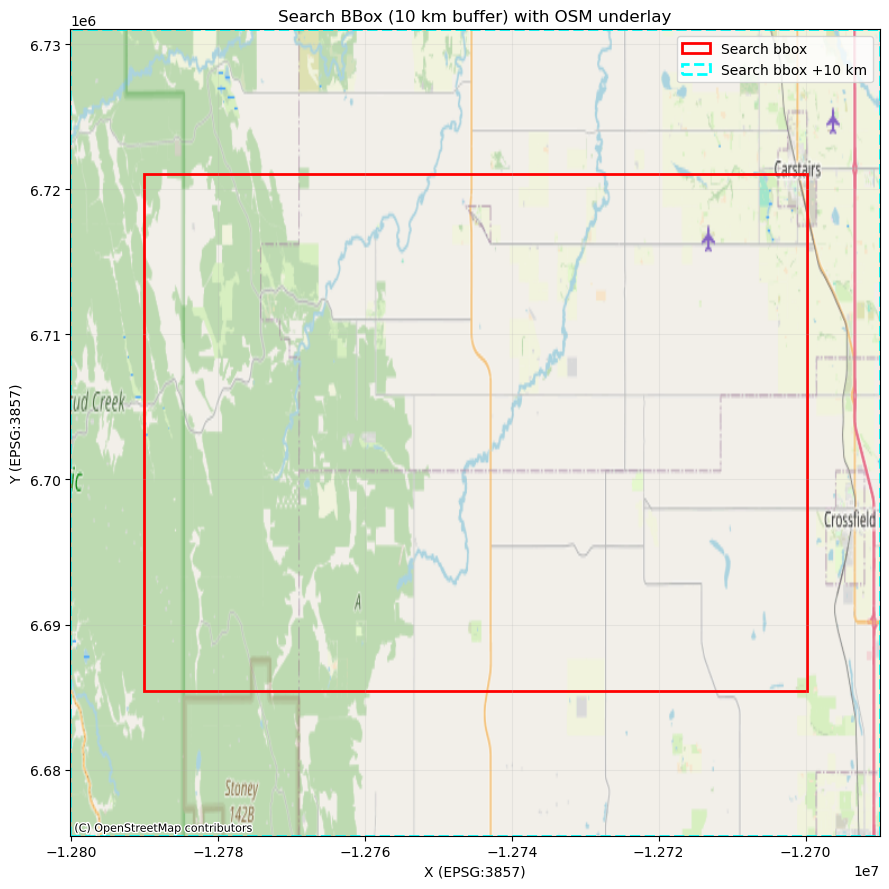

Search bbox (source CRS): (-114.895639271, 51.36125093, -114.084921156, 51.560328722)
Search bbox (EPSG:3857): (-12790124.058015363, 6685445.324615243, -12699875.330276683, 6721014.351771052)
Buffered bbox (EPSG:3857): (-12800124.058015363, 6675445.324615243, -12689875.330276683, 6731014.351771052)


In [6]:
# Plot the search bbox with a 10 km buffer on an OSM basemap.
# Buffer in EPSG:3857 meters so this works for projected and geographic source CRS.

# Convert search bounds to Web Mercator for OSM plotting via contextily.
bbox_3857 = transform_bounds(lowres_crs, "EPSG:3857", *lowres_bounds, densify_pts=21)

# Apply a 10 km buffer in EPSG:3857 units (meters).
buffer_m = 10_000
buffered_bbox_3857 = (
    bbox_3857[0] - buffer_m,
    bbox_3857[1] - buffer_m,
    bbox_3857[2] + buffer_m,
    bbox_3857[3] + buffer_m,
)

# Sanity checks to catch malformed bounds before plotting.
assert bbox_3857[0] < bbox_3857[2], "Invalid transformed bbox x ordering."
assert bbox_3857[1] < bbox_3857[3], "Invalid transformed bbox y ordering."
assert buffered_bbox_3857[0] < buffered_bbox_3857[2], "Invalid transformed buffered bbox x ordering."
assert buffered_bbox_3857[1] < buffered_bbox_3857[3], "Invalid transformed buffered bbox y ordering."

# Build figure and axis.
fig, ax = plt.subplots(figsize=(9, 9))

# Set extent to the buffered bbox first so contextily fetches tiles for the full area.
ax.set_xlim(buffered_bbox_3857[0], buffered_bbox_3857[2])
ax.set_ylim(buffered_bbox_3857[1], buffered_bbox_3857[3])

# Add OSM underlay.
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,
    crs="EPSG:3857",
)

# Draw the exact search bbox in red.
search_box = Rectangle(
    (bbox_3857[0], bbox_3857[1]),
    bbox_3857[2] - bbox_3857[0],
    bbox_3857[3] - bbox_3857[1],
    fill=False,
    edgecolor="red",
    linewidth=2,
    label="Search bbox",
)
ax.add_patch(search_box)

# Draw the 10 km buffered bbox in cyan dashed style.
buffer_box = Rectangle(
    (buffered_bbox_3857[0], buffered_bbox_3857[1]),
    buffered_bbox_3857[2] - buffered_bbox_3857[0],
    buffered_bbox_3857[3] - buffered_bbox_3857[1],
    fill=False,
    edgecolor="cyan",
    linewidth=2,
    linestyle="--",
    label="Search bbox +10 km",
)
ax.add_patch(buffer_box)

# Annotate and format plot.
ax.set_title("Search BBox (10 km buffer) with OSM underlay")
ax.set_xlabel("X (EPSG:3857)")
ax.set_ylabel("Y (EPSG:3857)")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Print bounds so they are visible in notebook outputs.
print("Search bbox (source CRS):", lowres_bounds)
print("Search bbox (EPSG:3857):", bbox_3857)
print("Buffered bbox (EPSG:3857):", buffered_bbox_3857)


## 04) Run STAC Query

Query the HRDEM LiDAR collection using the bbox from the low-res raster.


In [7]:
# Open STAC client and run search.
client = Client.open(STAC_URL)
search = client.search(
    collections=[COLLECTION],
    bbox=list(lowres_bbox_4326),
    limit=100,
)
items = list(search.items())

#print out the id of each item returned
for item in items:
    print(f"id: {item.id}")

# Enforce ADR behavior with explicit diagnostics if no intersection is found.
if len(items) == 0:
    raise RuntimeError(
        "No intersecting STAC items returned. "
        f"tile={LOWRES_FP}, bbox_4326={lowres_bbox_4326}, "
        f"collection={COLLECTION}, stac_url={STAC_URL}"
    )

# Keep only items that include the target asset to avoid downstream key errors.
items = [item for item in items if DEFAULT_ASSET in item.assets]
if len(items) == 0:
    raise RuntimeError(
        f"STAC returned items, but none include asset '{DEFAULT_ASSET}'."
    )

print(f"Returned {len(items)} STAC item(s) with asset '{DEFAULT_ASSET}'.")
for idx, item in enumerate(items, start=1):
    print(f"  {idx}. id={item.id} | assets={len(item.assets)}")


id: NRCAN-Calgary_West_utm11_2020-1m
Returned 1 STAC item(s) with asset 'dtm'.
  1. id=NRCAN-Calgary_West_utm11_2020-1m | assets=7


## 05) Display STAC Return

Show a concise but informative view of the first returned item and its assets.


In [8]:
# Inspect the first item in detail.
item = items[0]

print("First item summary:")
print(f"  id: {item.id}")
print(f"  datetime: {item.datetime}")
print(f"  geometry type: {item.geometry.get('type') if item.geometry else None}")
print(f"  bbox: {item.bbox}")
print("\nAsset keys:")
print(sorted(item.assets.keys()))

print("\nSelected asset metadata (dtm):")
assert DEFAULT_ASSET in item.assets, f"Expected asset '{DEFAULT_ASSET}' in first item."
asset = item.assets[DEFAULT_ASSET]
asset_overview = {
    "title": asset.title,
    "media_type": asset.media_type,
    "roles": asset.roles,
    "href": asset.href,
}
pprint(asset_overview)

print("\nAsset href selected for downstream fetch:")
print(asset.href)


First item summary:
  id: NRCAN-Calgary_West_utm11_2020-1m
  datetime: 2020-10-08 12:00:00+00:00
  geometry type: MultiPolygon
  bbox: [-114.444887, 50.775415, -113.962111, 51.504265]

Asset keys:
['coverage', 'dsm', 'dsm-vrt', 'dtm', 'dtm-vrt', 'extent', 'thumbnail']

Selected asset metadata (dtm):
{'href': 'https://canelevation-dem.s3.ca-central-1.amazonaws.com/hrdem-lidar/NRCAN-Calgary_West_utm11_2020-1m-dtm.tif',
 'media_type': 'image/tiff; application=geotiff; profile=cloud-optimized',
 'roles': ['data'],
 'title': 'Digital Terrain Model (COG) / Modèle numérique de terrain (COG)'}

Asset href selected for downstream fetch:
https://canelevation-dem.s3.ca-central-1.amazonaws.com/hrdem-lidar/NRCAN-Calgary_West_utm11_2020-1m-dtm.tif


## 06) Write STAC Return To GeoJSON

Write the full STAC item return to GeoJSON (one feature per item).


In [9]:
# Build a GeoJSON FeatureCollection from full STAC item payloads.
features = [item.to_dict() for item in items]
geojson_d = {
    "type": "FeatureCollection",
    "features": features,
}

# Validate export payload before writing.
assert len(geojson_d["features"]) == len(items), "Feature count mismatch in GeoJSON export."
assert all(ft.get("geometry") is not None for ft in geojson_d["features"]), "GeoJSON feature missing geometry."
assert all("properties" in ft for ft in geojson_d["features"]), "GeoJSON feature missing properties."
assert all("assets" in ft for ft in geojson_d["features"]), "Full STAC feature missing assets."
assert all("links" in ft for ft in geojson_d["features"]), "Full STAC feature missing links."

# Write GeoJSON to disk.
OUT_GEOJSON_FP.parent.mkdir(parents=True, exist_ok=True)
OUT_GEOJSON_FP.write_text(json.dumps(geojson_d, indent=2))

# Confirm file exists and print concise export details.
assert OUT_GEOJSON_FP.exists(), "Expected GeoJSON file to exist after write."
print(f"Wrote GeoJSON with {len(features)} feature(s):")
print(OUT_GEOJSON_FP.resolve())
print(f"Output size (bytes): {OUT_GEOJSON_FP.stat().st_size}")
print("Top-level keys from first feature:")
print(sorted(features[0].keys()))


Wrote GeoJSON with 1 feature(s):
/workspace/_scratch/hrdem-lidar_lores.geojson
Output size (bytes): 7776
Top-level keys from first feature:
['assets', 'bbox', 'collection', 'geometry', 'id', 'links', 'properties', 'stac_extensions', 'stac_version', 'type']


## 07) Quick Result Summary

If you reached this cell successfully, the pre-fetch query test worked:
- bbox extracted from local tile,
- STAC query returned LiDAR items,
- return converted to GeoJSON features,
- GeoJSON written to disk for downstream work.


In [10]:
# Print a compact final summary for quick verification in logs.
print("Final pre-fetch summary:")
print(f"  Collection: {COLLECTION}")
print(f"  STAC URL: {STAC_URL}")
print(f"  Query bbox (EPSG:4326): {lowres_bbox_4326}")
print(f"  Returned items: {len(items)}")
print(f"  GeoJSON: {OUT_GEOJSON_FP.resolve()}")


Final pre-fetch summary:
  Collection: hrdem-lidar
  STAC URL: https://datacube.services.geo.ca/api
  Query bbox (EPSG:4326): (-114.895639271, 51.36125093, -114.084921156, 51.560328722)
  Returned items: 1
  GeoJSON: /workspace/_scratch/hrdem-lidar_lores.geojson
